# Imports

In [1]:
from pathlib import Path
import re
from experimaestro.settings import get_workspace

#default_workspace_path 
ws = get_workspace()
xps_root = ws.path / "experiments"

def get_last_xp(xp_id, force_date=None):
    dates = list((xps_root / xp_id).glob("*"))
    print(f"Found dates for {xp_id}: {[d.name for d in dates]}")
    #parse and get most recent date
    try:
        most_recent_date = max(
            [d for d in dates if re.match(r'\d+_\d+', d.name)], 
            key=lambda d: d.name)
        print(f"Most recent date for {xp_id}: {most_recent_date.name}")
    except ValueError:
        print(f"No valid dates found for xp {xp_id}")
    
    if force_date is not None:
        forced_date_path = xps_root / xp_id / force_date
        if forced_date_path in dates:
            most_recent_date = forced_date_path
            print(f"Using forced date for {xp_id}: {most_recent_date.name}")
        else:
            raise ValueError(f"Forced date {force_date} not found for xp {xp_id}")
    return most_recent_date

print("found xps")
all_xps = list(xps_root.glob("*"))
for xp in all_xps:
    print(f"- {xp}") 


/home/vast/franken_minilm/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


found xps
- /home/vast/target_dir/franken_minilm/experiments/midFusion_ettin_17M_cls
- /home/vast/target_dir/franken_minilm/experiments/ettin_margin_mse_baseline
- /home/vast/target_dir/franken_minilm/experiments/debug_masked_minilm_margin_mse_step1
- /home/vast/target_dir/franken_minilm/experiments/ettin_merge_doc_query_embeddings
- /home/vast/target_dir/franken_minilm/experiments/ettin_masking_step3
- /home/vast/target_dir/franken_minilm/experiments/ettin_17M_margin_mse_masked_step01
- /home/vast/target_dir/franken_minilm/experiments/midFusion_ettin_17M_l2_cls
- /home/vast/target_dir/franken_minilm/experiments/ettin_32M_margin_mse_masked_step01
- /home/vast/target_dir/franken_minilm/experiments/ettin_17M_cls_margin_mse_baseline
- /home/vast/target_dir/franken_minilm/experiments/ettin_17M_masking_step1
- /home/vast/target_dir/franken_minilm/experiments/ettin_17M_masking_step2
- /home/vast/target_dir/franken_minilm/experiments/ettin_17M_search_merge_layer
- /home/vast/target_dir/franke

In [2]:
import matplotlib.pyplot as plt
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

# Figure 1

In [12]:
import re 
import pandas as pd
from IPython.display import display

xps = [
    "ettin_32M_search_merge_layer",
] 

def get_results(xp, force_date=None):
    most_recent_date = get_last_xp(xp, force_date)
    res_path = xps_root / xp / most_recent_date / "results"
    results_files = list(res_path.glob("*.csv"))
    print(f"Found results files for {xp}: {[f.name for f in results_files]}")
    results = pd.read_csv(res_path / "results.csv")
    labels1 = results.iloc[0]
    labels2 = results.iloc[1]
    labels = [f"{l1}{ '_' + l2 if str(l2) != 'nan' else ''}" for l1, l2 in zip(labels1, labels2)]
    labels[0] = 'dataset'
    results.columns = labels
    results = results.iloc[2:]

    #get drop layer from grid search column
    pattern = re.compile(r'l\d-(\d+)')
    results['merge_layer'] = results['grid_search'].apply(lambda x: int(pattern.search(x).group(1)) if isinstance(x, str) and pattern.search(x) else None)


    stats = pd.read_csv(res_path / "statistical_significance_results.csv")

    return results, stats

for xp in xps:
    # drop first row of results
    print("Results:")
    results, stats = get_results(
        xp,
        force_date = "dry-run"
        )
    display(results.head(10))
    print("Statistical Significance Results:")
    display(stats)
    

Results:
Found dates for ettin_32M_search_merge_layer: ['20260114_193105', 'dry-run', 'lock']
Most recent date for ettin_32M_search_merge_layer: 20260114_193105
Using forced date for ettin_32M_search_merge_layer: dry-run
Found results files for ettin_32M_search_merge_layer: ['results.csv', 'statistical_significance_results.csv']


,dataset,first_stage,scorer,grid_search,AP_mean,AP_var,RR@10_mean,RR@10_var,nDCG@10_mean,nDCG@10_var,merge_layer
2,msmarco_dev,bm25,NaN,NaN,0.1942,NaN,0.1855,NaN,0.2301,NaN,NaN
3,msmarco_dev,bm25,baseline-ettin_32M_search_merge_layer-0,attn_['query']2['document']_l0-0,0.36662,4.6156987e-05,0.36294,5.0743023e-05,0.42334,4.5913133e-05,0.0
4,msmarco_dev,bm25,ettin_32M_search_merge_layer-1,attn_['query']2['document']_l0-1,0.3599,0.00015005998,0.35586,0.00015954295,0.41599998,0.00017471501,1.0
5,msmarco_dev,bm25,ettin_32M_search_merge_layer-2,attn_['query']2['document']_l0-2,0.3653,6.3760075e-05,0.36138,6.7466994e-05,0.42209998,7.4410105e-05,2.0
6,msmarco_dev,bm25,ettin_32M_search_merge_layer-3,attn_['query']2['document']_l0-3,0.36076,0.00020141312,0.35683998,0.00021824791,0.41679996,0.00024688506,3.0
7,msmarco_dev,bm25,ettin_32M_search_merge_layer-4,attn_['query']2['document']_l0-4,0.36548,1.3969935e-06,0.36185998,1.6229841e-06,0.42212,1.4119903e-06,4.0
8,msmarco_dev,bm25,ettin_32M_search_merge_layer-5,attn_['query']2['document']_l0-5,0.3628,8.32502e-06,0.35918,8.137029e-06,0.41972,6.7570213e-06,5.0
9,msmarco_dev,bm25,ettin_32M_search_merge_layer-6,attn_['query']2['document']_l0-6,0.36198002,8.98698e-06,0.35832,8.527031e-06,0.41864,5.7529523e-06,6.0
10,msmarco_dev,bm25,ettin_32M_search_merge_layer-7,attn_['query']2['document']_l0-7,0.33814,1.4043108e-05,0.33324,1.5697997e-05,0.39202,1.492199e-05,7.0
11,msmarco_dev,bm25,ettin_32M_search_merge_layer-8,attn_['query']2['document']_l0-8,0.338,6.190022e-06,0.3332,6.4350056e-06,0.3917,5.4849943e-06,8.0


Statistical Significance Results:


,dataset,measure,model,t_stat,p_value,n_baseline,n_other
0,msmarco_dev,AP,ettin_32M_search_merge_layer-1-RR@10,1.076246,2.818360e-01,6980,6980
1,msmarco_dev,AP,ettin_32M_search_merge_layer-2-RR@10,0.210247,8.334781e-01,6980,6980
2,msmarco_dev,AP,ettin_32M_search_merge_layer-3-RR@10,0.941252,3.465922e-01,6980,6980
3,msmarco_dev,AP,ettin_32M_search_merge_layer-4-RR@10,0.181356,8.560905e-01,6980,6980
4,msmarco_dev,AP,ettin_32M_search_merge_layer-5-RR@10,0.609866,5.419605e-01,6980,6980
...,...,...,...,...,...,...,...
76,trec2020,nDCG@10,ettin_32M_search_merge_layer-5-RR@10,-0.059831,9.524030e-01,54,54
77,trec2020,nDCG@10,ettin_32M_search_merge_layer-6-RR@10,-0.011676,9.907062e-01,54,54
78,trec2020,nDCG@10,ettin_32M_search_merge_layer-7-RR@10,0.862576,3.903471e-01,54,54
79,trec2020,nDCG@10,ettin_32M_search_merge_layer-8-RR@10,1.268447,2.074874e-01,54,54


In [15]:
print(np.mean([44.1 , 73.1 , 71.8]))
print(np.mean([44.1 , 73.1 , 71.8 , 14.8 , 26.8 , 45.4 , 81.4 , 37.4 , 72.5 , 34.5 , 55.2 , 77.5 , 15.6 , 69.4 , 37.5 , 68.8]))

63.0
51.6125


In [13]:
import pandas as pd
import numpy as np

# 1. Define the metrics
metrics = ['AP', 'RR@10', 'nDCG@10']

metric_to_plot = 'nDCG@10'
# 2. Define the configuration columns
group_cols = ['first_stage', 'scorer', 'grid_search', 'merge_layer']

# 3. Ensure numeric types
all_cols = []
for m in metrics:
    all_cols.extend([f'{m}_mean', f'{m}_var'])

for col in all_cols:
    results[col] = pd.to_numeric(results[col], errors='coerce')

# 4. Compute the Simple Average of Means and Variances
#    We do NOT add the inter-dataset variance here.
#    We act as if the datasets are fixed strata.
aggregated_stats = results.groupby(group_cols, dropna=False)[all_cols].mean()

# 5. Rename columns for clarity
#    Renaming 'AP_mean' -> 'Grand_Mean_AP' and 'AP_var' -> 'Average_Var_AP'
rename_dict = {}
for m in metrics:
    rename_dict[f'{m}_mean'] = f'{m}_Grand_Mean'
    rename_dict[f'{m}_var']  = f'{m}_Average_Var'

aggregated_stats = aggregated_stats.rename(columns=rename_dict)

print(f"""found {len(results)} evals on datasets: 
      {', '.join(results['dataset'].unique())}""")

print("Aggregated Results (Average Variance only):")
display(aggregated_stats)


found 33 evals on datasets: 
      msmarco_dev, trec2019, trec2020
Aggregated Results (Average Variance only):


AP_Grand_Mean  \
first_stage scorer                                  grid_search                      merge_layer                  
bm25        baseline-ettin_32M_search_merge_layer-0 attn_['query']2['document']_l0-0 0.0               0.443867   
            ettin_32M_search_merge_layer-1          attn_['query']2['document']_l0-1 1.0               0.437033   
            ettin_32M_search_merge_layer-2          attn_['query']2['document']_l0-2 2.0               0.442107   
            ettin_32M_search_merge_layer-3          attn_['query']2['document']_l0-3 3.0               0.436240   
            ettin_32M_search_merge_layer-4          attn_['query']2['document']_l0-4 4.0               0.436953   
            ettin_32M_search_merge_layer-5          attn_['query']2['document']_l0-5 5.0               0.434620   
            ettin_32M_search_merge_layer-6          attn_['query']2['document']_l0-6 6.0               0.433280   
            ettin_32M_search_merge_layer-7          attn_['query']2['document']_l0-7 7.0               0.406013   
            ettin_32M_search_merge_layer-8          attn_['query']2['document']_l0-8 8.0               0.405547   
            ettin_32M_search_merge_layer-9          attn_['query']2['document']_l0-9 9.0               0.041500   
            NaN                                     NaN                              NaN               0.305633   

                                                                                                  AP_Average_Var  \
first_stage scorer                                  grid_search                      merge_layer                   
bm25        baseline-ettin_32M_search_merge_layer-0 attn_['query']2['document']_l0-0 0.0                0.000053   
            ettin_32M_search_merge_layer-1          attn_['query']2['document']_l0-1 1.0                0.000122   
            ettin_32M_search_merge_layer-2          attn_['query']2['document']_l0-2 2.0                0.000061   
            ettin_32M_search_merge_layer-3          attn_['query']2['document']_l0-3 3.0                0.000180   
            ettin_32M_search_merge_layer-4          attn_['query']2['document']_l0-4 4.0                0.000004   
            ettin_32M_search_merge_layer-5          attn_['query']2['document']_l0-5 5.0                0.000025   
            ettin_32M_search_merge_layer-6          attn_['query']2['document']_l0-6 6.0                0.000027   
            ettin_32M_search_merge_layer-7          attn_['query']2['document']_l0-7 7.0                0.000012   
            ettin_32M_search_merge_layer-8          attn_['query']2['document']_l0-8 8.0                0.000007   
            ettin_32M_search_merge_layer-9          attn_['query']2['document']_l0-9 9.0                0.000000   
            NaN                                     NaN                              NaN                     NaN   

                                                                                                  RR@10_Grand_Mean  \
first_stage scorer                                  grid_search                      merge_layer                     
bm25        baseline-ettin_32M_search_merge_layer-0 attn_['query']2['document']_l0-0 0.0                  0.749260   
            ettin_32M_search_merge_layer-1          attn_['query']2['document']_l0-1 1.0                  0.740553   
            ettin_32M_search_merge_layer-2          attn_['query']2['document']_l0-2 2.0                  0.742620   
            ettin_32M_search_merge_layer-3          attn_['query']2['document']_l0-3 3.0                  0.737753   
            ettin_32M_search_merge_layer-4          attn_['query']2['document']_l0-4 4.0                  0.746647   
            ettin_32M_search_merge_layer-5          attn_['query']2['document']_l0-5 5.0                  0.748533   
            ettin_32M_search_merge_layer-6          attn_['query']2['document']_l0-6 6.0                  0.746913   
            ettin_32M_search_me

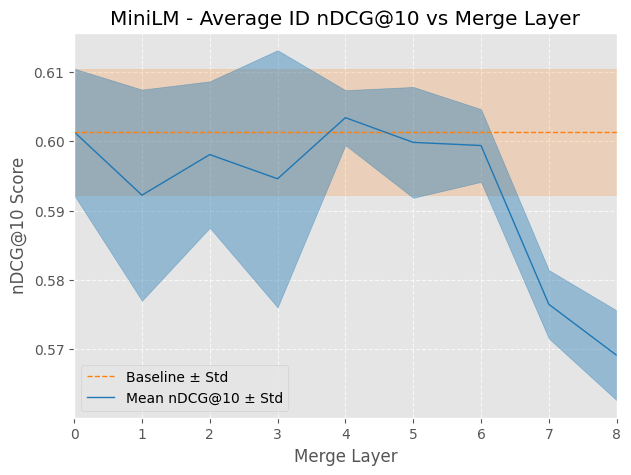

In [14]:
# --- PLOTTING (Updated for this logic) ---
import matplotlib.pyplot as plt
#use ACM style
plt.style.use('ggplot')

# Filter for plotting
plot_df = aggregated_stats.reset_index()
#keep only rows with merge_layer not null, sort by merge_layer
plot_df = plot_df[plot_df['merge_layer'].notnull()].sort_values(by='merge_layer')

# Calculate Average Standard Deviation (approx) from the Average Variance
# Note: Average(Std) != Sqrt(Average(Var)), but for error bars, Sqrt(Avg_Var) is the standard estimator for "Root Mean Square Error"
plot_df['nDCG_std_est'] = np.sqrt(plot_df[f'{metric_to_plot}_Average_Var'])

fig, ax = plt.subplots(figsize=(7, 5))

EXCLUDE_LAST = True

if EXCLUDE_LAST:
    plot_df = plot_df.iloc[:-1]

#plot baseline as horizontal line - baseline is first row 
baseline_value = plot_df[f'{metric_to_plot}_Grand_Mean'].iloc[0]
baseline_std_est = np.sqrt(plot_df[f'{metric_to_plot}_Average_Var'].iloc[0])
ax.axhline(
    y=baseline_value,
    color='tab:orange',
    linestyle='--',
    linewidth=1,
    label='Baseline ± Std'
)
#also plot shaded area for baseline std
ax.fill_between(
    plot_df['merge_layer'],
    baseline_value - baseline_std_est,
    baseline_value + baseline_std_est,
    color='tab:orange',
    alpha=0.2,
)   


# shaded envelope for mean ± estimated std
ax.fill_between(
    plot_df['merge_layer'],
    plot_df[f'{metric_to_plot}_Grand_Mean'] - plot_df['nDCG_std_est'],
    plot_df[f'{metric_to_plot}_Grand_Mean'] + plot_df['nDCG_std_est'],
    color='tab:blue',
    alpha=0.4,
)

ax.plot(
    plot_df['merge_layer'],
    plot_df[f'{metric_to_plot}_Grand_Mean'],
    '-',
    linewidth=1,
    color='tab:blue',
    label=f'Mean {metric_to_plot} ± Std'
 )

v_min, v_max = plot_df['merge_layer'].min(), plot_df['merge_layer'].max()

ax.set_title(f'MiniLM - Average ID {metric_to_plot} vs Merge Layer')
ax.set_xlabel('Merge Layer')
ax.set_xlim(v_min, v_max)
# ax.set_ylim(0.4, 0.55)
ax.set_ylabel(f'{metric_to_plot} Score')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
plt.show()
#save as pdf 
fig.savefig(f'figures/ettin_32M_average_ID_{metric_to_plot}_vs_merge_layer.pdf')


# Layer drop XP

In [3]:
import pandas as pd
import re
from IPython.display import display

xps = ["midFusion_ettin_32M_l6_drop_search", "midFusion_ettin_32M_l4_drop_search", "midFusion_ettin_17M_l3_drop_search"]

MODEL_TO_N_LAYERS = {
    "minilm": 12,
    "ettin_17M": 7,
    "ettin_32M": 10,
}

results_dict = {}

for xp in xps:
    if "minilm" in xp:
        n_layers = MODEL_TO_N_LAYERS["minilm"]
    elif "ettin_17M" in xp:
        n_layers = MODEL_TO_N_LAYERS["ettin_17M"]
    else:
        n_layers = MODEL_TO_N_LAYERS["ettin_32M"]

    print(xp, n_layers)
    most_recent_date = get_last_xp(xp, "dry-run")
    results_file = most_recent_date / "results" / "results.csv"
    if results_file.exists():
        print(f"Results for {xp}:")
        results = pd.read_csv(results_file)
        results_dict[xp] = (results, n_layers)
        display(results.head(15))
    else:
        print(f"No results found for {xp}.")

midFusion_ettin_32M_l6_drop_search 10
Found dates for midFusion_ettin_32M_l6_drop_search: ['20260117_144904', '20260117_155041', 'dry-run', 'lock']
Most recent date for midFusion_ettin_32M_l6_drop_search: 20260117_155041
Using forced date for midFusion_ettin_32M_l6_drop_search: dry-run
Results for midFusion_ettin_32M_l6_drop_search:


,dataset,tag,tag.1,metric,metric.1,metric.2,metric.3,metric.4,metric.5
0,NaN,first_stage,scorer,AP,AP,RR@10,RR@10,nDCG@10,nDCG@10
1,NaN,NaN,NaN,mean,var,mean,var,mean,var
2,msmarco_dev,bm25,baseline-ettin-drop=0_merge=6,0.36688,3.6020137e-06,0.36318,4.0570026e-06,0.4241,6.1150463e-06
3,msmarco_dev,bm25,ettin-drop=7_merge=6,0.0049400004,7.999971e-09,0.00024000001,3.000001e-09,0.00078,1.1999996e-08
4,msmarco_dev,bm25,ettin-drop=8_merge=6,0.35758,4.4806897e-05,0.35346,4.9347902e-05,0.4144,4.5735058e-05
5,msmarco_dev,bm25,ettin-drop=9_merge=6,0.36138,7.106953e-06,0.35758,8.232018e-06,0.41866,6.3329862e-06
6,trec2019,bm25,baseline-ettin-drop=0_merge=6,0.49025998,5.618011e-06,0.9616,9.4405405e-05,0.70326,4.6073263e-05
7,trec2019,bm25,ettin-drop=7_merge=6,0.063880004,4.0269974e-06,0.05348,7.3177005e-05,0.03062,0.00011783198
8,trec2019,bm25,ettin-drop=8_merge=6,0.47654,6.981824e-05,0.94956,5.416799e-05,0.69456,0.000111827925
9,trec2019,bm25,ettin-drop=9_merge=6,0.48504,8.863066e-06,0.95,0.0002473342,0.6926,7.688471e-05


midFusion_ettin_32M_l4_drop_search 10
Found dates for midFusion_ettin_32M_l4_drop_search: ['20260119_154338', 'dry-run', 'lock']
Most recent date for midFusion_ettin_32M_l4_drop_search: 20260119_154338
Using forced date for midFusion_ettin_32M_l4_drop_search: dry-run
Results for midFusion_ettin_32M_l4_drop_search:


,dataset,tag,tag.1,metric,metric.1,metric.2,metric.3,metric.4,metric.5
0,NaN,first_stage,scorer,AP,AP,RR@10,RR@10,nDCG@10,nDCG@10
1,NaN,NaN,NaN,mean,var,mean,var,mean,var
2,msmarco_dev,bm25,baseline-vanilla-ettin,0.374,7.5749817e-06,0.3707,8.849997e-06,0.43126002,1.0748033e-05
3,msmarco_dev,bm25,ettin-drop=5_merge=4,0.00488,6.9999864e-09,0.00024000001,3.000001e-09,0.00066,7.999998e-09
4,msmarco_dev,bm25,ettin-drop=6_merge=4,0.32782,2.7699832e-07,0.32268,5.770065e-07,0.38014,5.879851e-07
5,msmarco_dev,bm25,ettin-drop=7_merge=4,0.33998,1.8676981e-05,0.33502,2.142206e-05,0.3944,2.2690008e-05
6,msmarco_dev,bm25,ettin-drop=8_merge=4,0.34487998,8.559716e-05,0.34024,9.680301e-05,0.39946,0.00010037823
7,msmarco_dev,bm25,ettin-drop=9_merge=4,0.35282,4.1086972e-05,0.34903997,4.4202963e-05,0.40936002,4.9722934e-05
8,trec2019,bm25,baseline-vanilla-ettin,0.49978,2.5087118e-05,0.94332,1.9181914e-05,0.70302,0.00011100691
9,trec2019,bm25,ettin-drop=5_merge=4,0.065740004,6.0079983e-06,0.04688,6.8721994e-05,0.033859998,0.00010130799


midFusion_ettin_17M_l3_drop_search 7
Found dates for midFusion_ettin_17M_l3_drop_search: ['dry-run', '20260117_152529', '20260117_223306', '20260118_002700', 'lock']
Most recent date for midFusion_ettin_17M_l3_drop_search: 20260118_002700
Using forced date for midFusion_ettin_17M_l3_drop_search: dry-run
Results for midFusion_ettin_17M_l3_drop_search:


,dataset,tag,tag.1,metric,metric.1,metric.2,metric.3,metric.4,metric.5
0,NaN,first_stage,scorer,AP,AP,RR@10,RR@10,nDCG@10,nDCG@10
1,NaN,NaN,NaN,mean,var,mean,var,mean,var
2,msmarco_dev,bm25,baseline-vanilla-ettin,0.33218,2.2069974e-06,0.32694,2.352967e-06,0.38542,3.0370081e-06
3,msmarco_dev,bm25,ettin-drop=4_merge=3,0.0049,1.9999923e-08,0.00019999998,5.0000013e-09,0.00076,1.2999998e-08
4,msmarco_dev,bm25,ettin-drop=5_merge=3,0.31448,3.198194e-05,0.30844,3.2952907e-05,0.36622,4.2517073e-05
5,msmarco_dev,bm25,ettin-drop=6_merge=3,0.32639998,6.0700527e-06,0.32096,7.163061e-06,0.3796,6.3399903e-06
6,trec2019,bm25,baseline-vanilla-ettin,0.45282,4.3342046e-05,0.91448003,0.00056953245,0.65076,0.000101952835
7,trec2019,bm25,ettin-drop=4_merge=3,0.06372,2.066995e-06,0.040799998,9.698997e-05,0.031799998,0.000117214986
8,trec2019,bm25,ettin-drop=5_merge=3,0.43702,4.5272027e-05,0.9174601,0.00031858834,0.65436,0.0003221537
9,trec2019,bm25,ettin-drop=6_merge=3,0.45254,4.6617948e-05,0.91543996,0.000108807995,0.65698,0.0001421615


In [4]:
from pathlib import Path 
import pandas as pd
import re 

metrics = ['AP', 'RR@10', 'nDCG@10']

processed_results = {}

for xp, (results, n_layers) in results_dict.items():
    print(f"\n=== Processing {xp} ===")
    
    labels1 = results.iloc[0]
    labels2 = results.iloc[1]
    labels = [f"{l1}{ '_' + str(l2) if str(l2) != 'nan' else ''}" for l1, l2 in zip(labels1, labels2)]
    labels[0] = 'dataset'
    results.columns = labels
    results = results.iloc[2:]

    #get drop layer from grid search column
    pattern = re.compile(r'drop=(\d+)_')

    def get_drop_layer(row):
        scorer = row['scorer']
        print(scorer)
        if "baseline" in scorer: return n_layers
        try:
            match = pattern.search(scorer)
            return int(match.group(1))
        except:
            return None

    def get_merge_layer(row):
        scorer = row['scorer']
        try:
            match = re.compile(r'merge=(\d+)').search(scorer)
            return int(match.group(1))
        except: 
            return None

    def get_n_top(row):
        try:
            return row['drop_layer'] - row['merge_layer']
        except:
            return None
        

    results['drop_layer'] = results.apply(get_drop_layer, axis=1)
    print(results['drop_layer'])
    results['merge_layer'] = results.apply(get_merge_layer, axis=1)
    results['n_top'] = results.apply(get_n_top, axis=1)
    results['n_dropped'] = results['drop_layer'].apply(lambda x: n_layers - x if x is not None else None)

    display(results.sort_values(by='drop_layer', ascending=False))

    metric_to_plot = 'nDCG@10'
    # 2. Define the configuration columns
    group_cols = ['first_stage', 'scorer', 'drop_layer', 'n_dropped', 'merge_layer', 'n_top']

    # 3. Ensure numeric types
    all_cols = []
    for m in metrics:
        all_cols.extend([f'{m}_mean', f'{m}_var'])

    for col in all_cols:
        results[col] = pd.to_numeric(results[col], errors='coerce')

    # 4. Compute the Simple Average of Means and Variances
    #    We do NOT add the inter-dataset variance here.
    #    We act as if the datasets are fixed strata.
    aggregated_stats = results.groupby(group_cols, dropna=False)[all_cols].mean()

    # 5. Rename columns for clarity
    #    Renaming 'AP_mean' -> 'Grand_Mean_AP' and 'AP_var' -> 'Average_Var_AP'
    rename_dict = {}
    for m in metrics:
        rename_dict[f'{m}_mean'] = f'{m}_Grand_Mean'
        rename_dict[f'{m}_var']  = f'{m}_Average_Var'

    aggregated_stats = aggregated_stats.rename(columns=rename_dict)
    
    # Add experiment label
    aggregated_stats['xp'] = xp
    
    processed_results[xp] = aggregated_stats

    print(f"Aggregated Results for {xp}:")
    display(aggregated_stats)


=== Processing midFusion_ettin_32M_l6_drop_search ===
baseline-ettin-drop=0_merge=6
ettin-drop=7_merge=6
ettin-drop=8_merge=6
ettin-drop=9_merge=6
baseline-ettin-drop=0_merge=6
ettin-drop=7_merge=6
ettin-drop=8_merge=6
ettin-drop=9_merge=6
baseline-ettin-drop=0_merge=6
ettin-drop=7_merge=6
ettin-drop=8_merge=6
ettin-drop=9_merge=6
2     10
3      7
4      8
5      9
6     10
7      7
8      8
9      9
10    10
11     7
12     8
13     9
Name: drop_layer, dtype: int64


/tmp/ipykernel_373263/533760847.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['drop_layer'] = results.apply(get_drop_layer, axis=1)
/tmp/ipykernel_373263/533760847.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['merge_layer'] = results.apply(get_merge_layer, axis=1)
/tmp/ipykernel_373263/533760847.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

,dataset,first_stage,scorer,AP_mean,AP_var,RR@10_mean,RR@10_var,nDCG@10_mean,nDCG@10_var,drop_layer,merge_layer,n_top,n_dropped
2,msmarco_dev,bm25,baseline-ettin-drop=0_merge=6,0.36688,3.6020137e-06,0.36318,4.0570026e-06,0.4241,6.1150463e-06,10,6,4,0
6,trec2019,bm25,baseline-ettin-drop=0_merge=6,0.49025998,5.618011e-06,0.9616,9.4405405e-05,0.70326,4.6073263e-05,10,6,4,0
10,trec2020,bm25,baseline-ettin-drop=0_merge=6,0.47068,1.1602e-05,0.94526005,0.0003593274,0.69476,2.3337892e-05,10,6,4,0
5,msmarco_dev,bm25,ettin-drop=9_merge=6,0.36138,7.106953e-06,0.35758,8.232018e-06,0.41866,6.3329862e-06,9,6,3,1
13,trec2020,bm25,ettin-drop=9_merge=6,0.46992,4.716957e-06,0.93698007,4.1306954e-05,0.68398,1.7251961e-05,9,6,3,1
9,trec2019,bm25,ettin-drop=9_merge=6,0.48504,8.863066e-06,0.95,0.0002473342,0.6926,7.688471e-05,9,6,3,1
12,trec2020,bm25,ettin-drop=8_merge=6,0.46308002,6.222719e-05,0.95173997,6.566318e-05,0.6873,0.00020118494,8,6,2,2
4,msmarco_dev,bm25,ettin-drop=8_merge=6,0.35758,4.4806897e-05,0.35346,4.9347902e-05,0.4144,4.5735058e-05,8,6,2,2
8,trec2019,bm25,ettin-drop=8_merge=6,0.47654,6.981824e-05,0.94956,5.416799e-05,0.69456,0.000111827925,8,6,2,2
3,msmarco_dev,bm25,ettin-drop=7_merge=6,0.0049400004,7.999971e-09,0.00024000001,3.000001e-09,0.00078,1.1999996e-08,7,6,1,3


Aggregated Results for midFusion_ettin_32M_l6_drop_search:


/tmp/ipykernel_373263/533760847.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results[col] = pd.to_numeric(results[col], errors='coerce')


...

/tmp/ipykernel_373263/533760847.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['drop_layer'] = results.apply(get_drop_layer, axis=1)
/tmp/ipykernel_373263/533760847.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['merge_layer'] = results.apply(get_merge_layer, axis=1)
/tmp/ipykernel_373263/533760847.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

,dataset,first_stage,scorer,AP_mean,AP_var,RR@10_mean,RR@10_var,nDCG@10_mean,nDCG@10_var,drop_layer,merge_layer,n_top,n_dropped
2,msmarco_dev,bm25,baseline-vanilla-ettin,0.33218,2.2069974e-06,0.32694,2.352967e-06,0.38542,3.0370081e-06,7,NaN,NaN,0
6,trec2019,bm25,baseline-vanilla-ettin,0.45282,4.3342046e-05,0.91448003,0.00056953245,0.65076,0.000101952835,7,NaN,NaN,0
10,trec2020,bm25,baseline-vanilla-ettin,0.42775998,1.4043e-05,0.916,8.634518e-05,0.63478005,0.00017261734,7,NaN,NaN,0
5,msmarco_dev,bm25,ettin-drop=6_merge=3,0.32639998,6.0700527e-06,0.32096,7.163061e-06,0.3796,6.3399903e-06,6,3.0,3.0,1
13,trec2020,bm25,ettin-drop=6_merge=3,0.43322,3.6726855e-05,0.88336,0.00042284362,0.6245,0.00010588023,6,3.0,3.0,1
9,trec2019,bm25,ettin-drop=6_merge=3,0.45254,4.6617948e-05,0.91543996,0.000108807995,0.65698,0.0001421615,6,3.0,3.0,1
12,trec2020,bm25,ettin-drop=5_merge=3,0.41656,9.097322e-05,0.86535996,0.0006766275,0.6057,0.0003608751,5,3.0,2.0,2
4,msmarco_dev,bm25,ettin-drop=5_merge=3,0.31448,3.198194e-05,0.30844,3.2952907e-05,0.36622,4.2517073e-05,5,3.0,2.0,2
8,trec2019,bm25,ettin-drop=5_merge=3,0.43702,4.5272027e-05,0.9174601,0.00031858834,0.65436,0.0003221537,5,3.0,2.0,2
3,msmarco_dev,bm25,ettin-drop=4_merge=3,0.0049,1.9999923e-08,0.00019999998,5.0000013e-09,0.00076,1.2999998e-08,4,3.0,1.0,3


Aggregated Results for midFusion_ettin_17M_l3_drop_search:


/tmp/ipykernel_373263/533760847.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results[col] = pd.to_numeric(results[col], errors='coerce')


AP_Grand_Mean  \
first_stage scorer                 drop_layer n_dropped merge_layer n_top                  
bm25        baseline-vanilla-ettin 7          0         NaN         NaN         0.404253   
            ettin-drop=4_merge=3   4          3         3.0         1.0         0.037567   
            ettin-drop=5_merge=3   5          2         3.0         2.0         0.389353   
            ettin-drop=6_merge=3   6          1         3.0         3.0         0.404053   

                                                                           AP_Average_Var  \
first_stage scorer                 drop_layer n_dropped merge_layer n_top                   
bm25        baseline-vanilla-ettin 7          0         NaN         NaN          0.000020   
            ettin-drop=4_merge=3   4          3         3.0         1.0          0.000003   
            ettin-drop=5_merge=3   5          2         3.0         2.0          0.000056   
            ettin-drop=6_merge=3   6          1         3.0         3.0          0.000030   

                                                                           RR@10_Grand_Mean  \
first_stage scorer                 drop_layer n_dropped merge_layer n_top                     
bm25        baseline-vanilla-ettin 7          0         NaN         NaN            0.719140   
            ettin-drop=4_merge=3   4          3         3.0         1.0            0.046867   
            ettin-drop=5_merge=3   5          2         3.0         2.0            0.697087   
            ettin-drop=6_merge=3   6          1         3.0         3.0            0.706587   

                                                                           RR@10_Average_Var  \
first_stage scorer                 drop_layer n_dropped merge_layer n_top                      
bm25        baseline-vanilla-ettin 7          0         NaN         NaN             0.000219   
            ettin-drop=4_merge=3   4          3         3.0         1.0             0.000227   
            ettin-drop=5_merge=3   5          2         3.0         2.0             0.000343   
            ettin-drop=6_merge=3   6          1         3.0         3.0             0.000180   

                                                                           nDCG@10_Grand_Mean  \
first_stage scorer                 drop_layer n_dropped merge_layer n_top                       
bm25        baseline-vanilla-ettin 7          0         NaN         NaN              0.556987   
            ettin-drop=4_merge=3   4          3         3.0         1.0              0.013847   
            ettin-drop=5_merge=3   5          2         3.0         2.0              0.542093   
            ettin-drop=6_merge=3   6          1         3.0         3.0              0.553693   

                                                                           nDCG@10_Average_Var  \
first_stage scorer                 drop_layer n_dropped merge_layer n_top                        
bm25        baseline-vanilla-ettin 7          0         NaN         NaN               0.000093   
            ettin-drop=4_merge=3   4          3         3.0         1.0               0.000046   
            ettin-drop=5_merge=3   5          2         3.0         2.0               0.000242   
            ettin-drop=6_merge=3   6          1         3.0         3.0               0.000085   

                                                                                                           xp  
first_stage scorer                 drop_layer n_dropped merge_layer n_top                                      
bm25        baseline-vanilla-ettin 7          0         NaN         NaN    midFusion_ettin_17M_l3_drop_search  
            ettin-drop=4_merge=3   4          3         3.0         1.0    midFusion_ettin_17M_l3_drop_search  
            ettin-drop=5_merge=3   5          2         3.0         2.0    midFusion_ettin_17M_l3_drop_search  
            ettin-drop=6_merge=3   6          1         3.0         3.0    midFusio

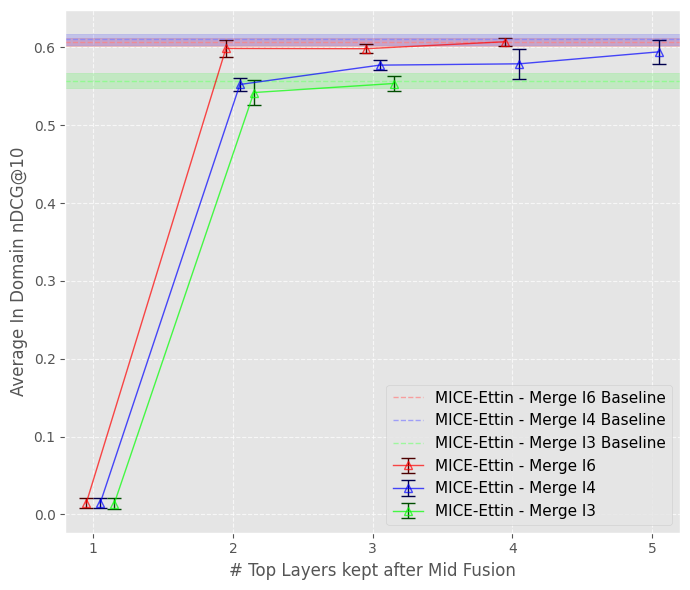

In [6]:
#plot both experiments on same figure
import numpy as np
from matplotlib.ticker import FixedLocator
import matplotlib.pyplot as plt
#use ACM style
plt.style.use('ggplot')

key = 'n_top'
MARGIN = 0.2
SHIFT = 0.1
metric_to_plot = 'nDCG@10'

fig, ax = plt.subplots(figsize=(7,6))

# Color map for different experiments
colors = [
    np.array((1, 0, 0, 0.7)), # red 
    np.array((0, 0, 1, 0.7)), # blue
    np.array((0, 1, 0, 0.7)), # green
]
white = np.array((1, 1, 1, 1))

experiment_labels = {
    'midFusion_ettin_32M_l6_drop_search': 'MICE-Ettin - Merge l6',
    'midFusion_ettin_32M_l4_drop_search': 'MICE-Ettin - Merge l4',
    'midFusion_ettin_17M_l3_drop_search': 'MICE-Ettin - Merge l3',
}

# Calculate min/max for margin
v_min = min([aggregated_stats.reset_index()[key].min() for aggregated_stats in processed_results.values()])
v_max = max([aggregated_stats.reset_index()[key].max() for aggregated_stats in processed_results.values()])

# Create x range for fill_between including margins
x_fill_range = np.linspace(v_min - MARGIN, v_max + MARGIN, 100)

for idx, (xp, aggregated_stats) in enumerate(processed_results.items()):
    # Filter for plotting
    plot_df = aggregated_stats.reset_index()
    #keep only rows with drop_layer not null, sort by key
    plot_df = plot_df[plot_df['drop_layer'].notnull()].sort_values(by=key)
    
    # Calculate Average Standard Deviation (approx) from the Average Variance
    plot_df['nDCG_std_est'] = np.sqrt(plot_df[f'{metric_to_plot}_Average_Var'])
    
    color = colors[idx]
    label = experiment_labels[xp]
    
    # Plot baseline as horizontal line (first run with n_dropped == 0)
    baseline_row = plot_df[plot_df['n_dropped'] == 0].iloc[0]
    baseline_value = baseline_row[f'{metric_to_plot}_Grand_Mean']
    baseline_std_est = np.sqrt(baseline_row[f'{metric_to_plot}_Average_Var'])
    
    # Draw baseline for this experiment with same color and alpha=0.7
    ax.axhline(
        y=baseline_value,
        color=(color + white) / 2,
        linestyle='--',
        linewidth=1,
        alpha=0.7,
        label=f'{label} Baseline'
    )
    #also plot shaded area for baseline std (including margins)
    ax.fill_between(
        x_fill_range,
        baseline_value - baseline_std_est,
        baseline_value + baseline_std_est,
        color=color,
        alpha=0.15,
    )
    x_vals = plot_df[key] + (idx - 0.5) * SHIFT
    # Plot error bars for this experiment
    ecolor = color * 0.3
    ecolor[-1] = 1.0  # ensure alpha is 1 for error bars
    ax.errorbar(
        x_vals,
        plot_df[f'{metric_to_plot}_Grand_Mean'],
        yerr=plot_df['nDCG_std_est'],
        linewidth=1,
        color=color,
        # darker version of color for error bars
        ecolor=ecolor,
        elinewidth=1,
        capsize=5,
        label=label,
        marker='^',
        markerfacecolor='none',
        markersize=6,   
    )

# ax.set_title('Layer Dropping Experiments', fontsize=14)
ax.set_xlabel('# Top Layers kept after Mid Fusion', fontsize=12)
ax.set_xlim(v_min - MARGIN, v_max + MARGIN)
ax.set_ylabel(f'Average In Domain {metric_to_plot}', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=11, loc='lower right')
ax.xaxis.set_major_locator(FixedLocator([1, 2, 3, 4, 5, 6]))
ax.set_xticklabels(['1', '2', '3', '4', '5', '6'])
plt.tight_layout()
plt.show()

# fig.savefig(f'figures/ettin_layer_dropping_ID_{metric_to_plot}.pdf')